In [17]:
'''
This file computes statistics for the deterministic Gottwald model and compares them to the stochastic model to ensure the 
calculated noise terms are adequately modelled AKA agree with the deterministic model.
The statistics calculated are as follows:
1. mean of T and S
2. Variance adn covariance of T and S
3. probability density of T and S
4. autocorrelation function of T and S
'''

'\nThis file computes statistics for the deterministic Gottwald model and compares them to the stochastic model to ensure the \ncalculated noise terms are adequately modelled AKA agree with the deterministic model.\nThe statistics calculated are as follows:\n1. mean of T and S\n2. Variance adn covariance of T and S\n3. probability density of T and S\n4. autocorrelation function of T and S\n'

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
control_run = pd.read_csv("../data/control_run5000_year.csv")


In [20]:
control_run.head()

,t,x,y,z,T,S,S0,T0,AMOC
0,0.00,1.000000,0.500000,0.500000,0.500000,0.500000,0.5,0.5,0.000000
1,0.01,1.295725,0.843484,1.110818,0.509284,0.503926,0.5,0.5,0.005357
2,0.02,0.385385,-0.824066,0.877369,0.518142,0.507790,0.5,0.5,0.010352
3,0.03,1.390310,0.536293,-0.560045,0.525255,0.511188,0.5,0.5,0.014067
4,0.04,0.903164,-0.761680,1.651970,0.532088,0.514654,0.5,0.5,0.017433


<Axes: xlabel='t', ylabel='T'>

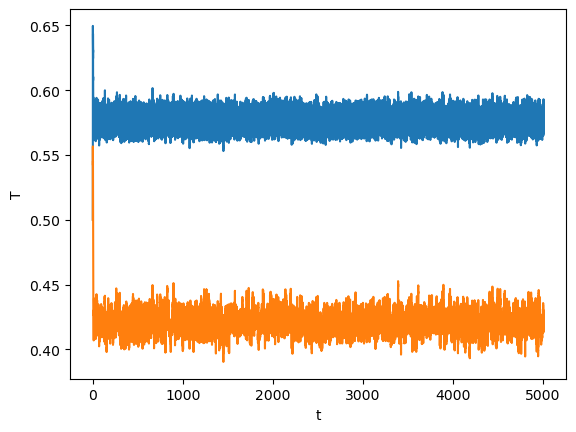

In [28]:
sns.lineplot(data=control_run,x='t',y='T')
sns.lineplot(data=control_run,x='t',y='S')

In [21]:
#means of T and S, d model
print(control_run['T'].mean())
print(control_run['S'].mean())

0.5754793516274861
0.4213137973741201


In [27]:
#variance of S and T
print(control_run['T'].var())
print(control_run['S'].var())
#covariance
cov_TS = ((control_run['T'] - control_run['T'].mean()) * (control_run['S'] - control_run['S'].mean())).mean() 
print(cov_TS)

2.9617477380599983e-05
7.148222414980511e-05
2.432991595977007e-05


(array([2.00000e+00, 2.00000e+00, 2.00000e+00, 2.45000e+02, 2.31819e+05,
        2.66140e+05, 2.43500e+03, 1.04000e+02, 1.04000e+02, 1.47000e+02]),
 array([0.5       , 0.51495491, 0.52990983, 0.54486474, 0.55981965,
        0.57477457, 0.58972948, 0.6046844 , 0.61963931, 0.63459422,
        0.64954914]),
 <BarContainer object of 10 artists>)

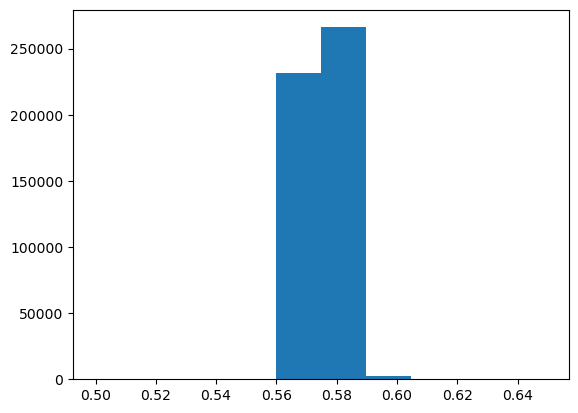

In [23]:
plt.hist(control_run['T'])

(array([1.58970e+04, 2.96090e+05, 1.83281e+05, 5.28600e+03, 7.20000e+01,
        3.70000e+01, 7.30000e+01, 4.00000e+01, 4.60000e+01, 1.78000e+02]),
 array([0.39026433, 0.40689486, 0.42352539, 0.44015592, 0.45678645,
        0.47341698, 0.4900475 , 0.50667803, 0.52330856, 0.53993909,
        0.55656962]),
 <BarContainer object of 10 artists>)

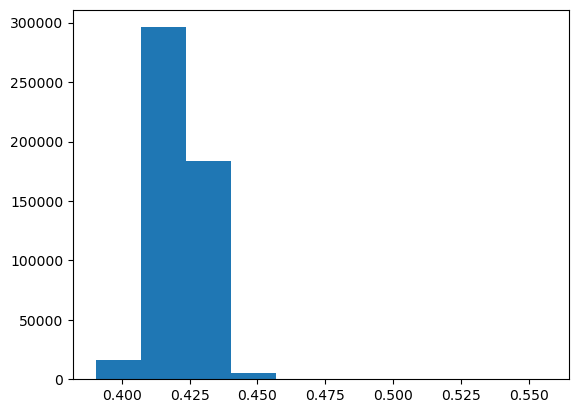

In [4]:
plt.hist(control_run['S'])

In [25]:
def autocorrelation(var):
    target_list = np.array(var)
    print(len(target_list))
    num_slices = 1000
    slice_length = len(target_list) // num_slices
    
    #Split series into slices
    slices = np.array_split(target_list, num_slices)
    
    #Initialize array to store ACF for each slice
    expectations = np.zeros((num_slices, slice_length))
    
    for slice_num, s in enumerate(slices):
        s = np.array(s)
        mean_s = np.mean(s)
        var_s = np.var(s)
    
        #Compute autocovariance for each lag
        for lag in range(slice_length):
            #Take all overlapping pairs at this lag, s[:len(s)-lag] -> all except last values, (s[lag:]) -> all except first vals
            products = (s[:len(s)-lag] - mean_s) * (s[lag:] - mean_s)
            expectations[slice_num, lag] = np.mean(products) / var_s 
    
    #Average ACF across slices
    ACF = np.mean(expectations, axis=0)
    
    return ACF

501000


Text(0, 0.5, 'Auto-correlation')

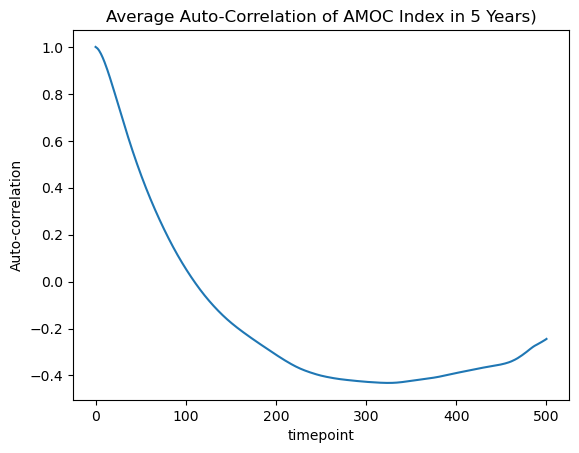

In [26]:
#plot autocorrelation function
#title_var = slice_length/10
ACF_s = autocorrelation(control_run['S'])
plt.figure()
plt.plot(ACF_s)
plt.title(f"Average Auto-Correlation of AMOC Index in 5 Years)")
plt.xlabel('timepoint')
plt.ylabel('Auto-correlation')
#plt.savefig('acfunc_salt.png')

501000


Text(0, 0.5, 'Auto-correlation')

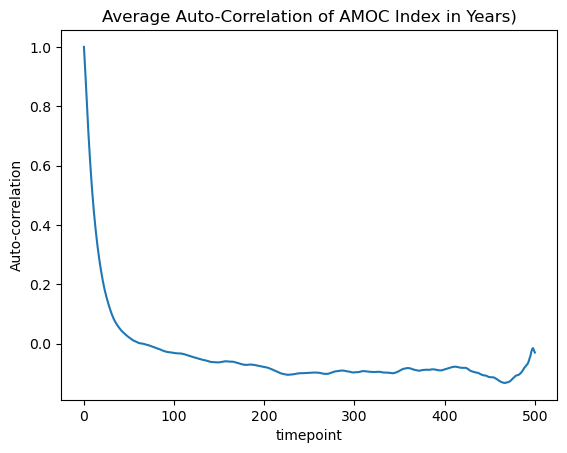

In [16]:
#plot autocorrelation function
#title_var = slice_length/10
ACF_t = autocorrelation(control_run['T'])
plt.figure()
plt.plot(ACF_t)
plt.title(f"Average Auto-Correlation of AMOC Index in 5 Years)")
plt.xlabel('timepoint')
plt.ylabel('Auto-correlation')
#plt.savefig('acfunc_salt.png')